# Intelligent Image Search RAG on a Local Images Folder

This notebook follows the same steps to the local `Images` folder in this project.

We will:

1. Generate rich metadata for each image using Gemini
2. Save that metadata as JSON
3. Create embeddings from the metadata
4. Store everything in ChromaDB
5. Retrieve the most relevant images for a query
6. Use those retrieved results in a final RAG answer


## Install Libraries


In [2]:
!pip install -U -q langchain-google-genai langchain-chroma chromadb "pillow<12"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 52.9 MB/s eta 0:00:00


In [8]:
import os
from pathlib import Path
from google.colab import userdata

if not os.getenv("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

PROJECT_DIR = Path.cwd()
IMAGE_DIR = PROJECT_DIR / "sample_data" / "Images"
JSON_DIR = PROJECT_DIR / "generated_metadata"
CHROMA_DIR = PROJECT_DIR / "chroma_db"

JSON_DIR.mkdir(parents=True, exist_ok=True)
CHROMA_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Image directory:", IMAGE_DIR)
print("Metadata directory:", JSON_DIR)
print("Chroma directory:", CHROMA_DIR)

Project directory: /content
Image directory: /content/sample_data/Images
Metadata directory: /content/generated_metadata
Chroma directory: /content/chroma_db


## Prompt for Image Metadata


In [4]:
image_description_prompt = '''
**Role:**
You are an expert Computer Vision Metadata Specialist and SEO Archivist. You create rich, search-friendly descriptions for image retrieval systems.

**Task:**
Analyze the provided image and generate a structured JSON object with:
- main_subject
- detailed_description
- visual_elements
- text_content
- search_keywords
- dominant_mood
- likely_setting

**Constraints:**
1. Description must be objective and factual in 2-3 sentences.
2. If visible text is absent, return null.
3. Provide 10-15 search keywords.
4. Return raw JSON only.

**Output format:**
{
  "main_subject": "String",
  "detailed_description": "String",
  "visual_elements": ["String", "String"],
  "text_content": "String or null",
  "search_keywords": ["String", "String"],
  "dominant_mood": "String",
  "likely_setting": "String"
}
'''


## Load the Model and Helper Functions


In [5]:
import base64
import json
import mimetypes
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2,
)

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

def generate_search_metadata(image_path, llm, prompt_text):
    mime_type, _ = mimetypes.guess_type(str(image_path))
    if not mime_type:
        mime_type = "image/jpeg"

    img_base64 = encode_image(image_path)

    message = HumanMessage(
        content=[
            {"type": "text", "text": prompt_text},
            {"type": "image_url", "image_url": {"url": f"data:{mime_type};base64,{img_base64}"}},
        ]
    )

    response = llm.invoke([message])
    return response.content.replace("```json", "").replace("```", "").strip()


## Process One Image


Total images found: 17
Sample image: alvan-nee-_mX0sSpVbOg-unsplash.jpg


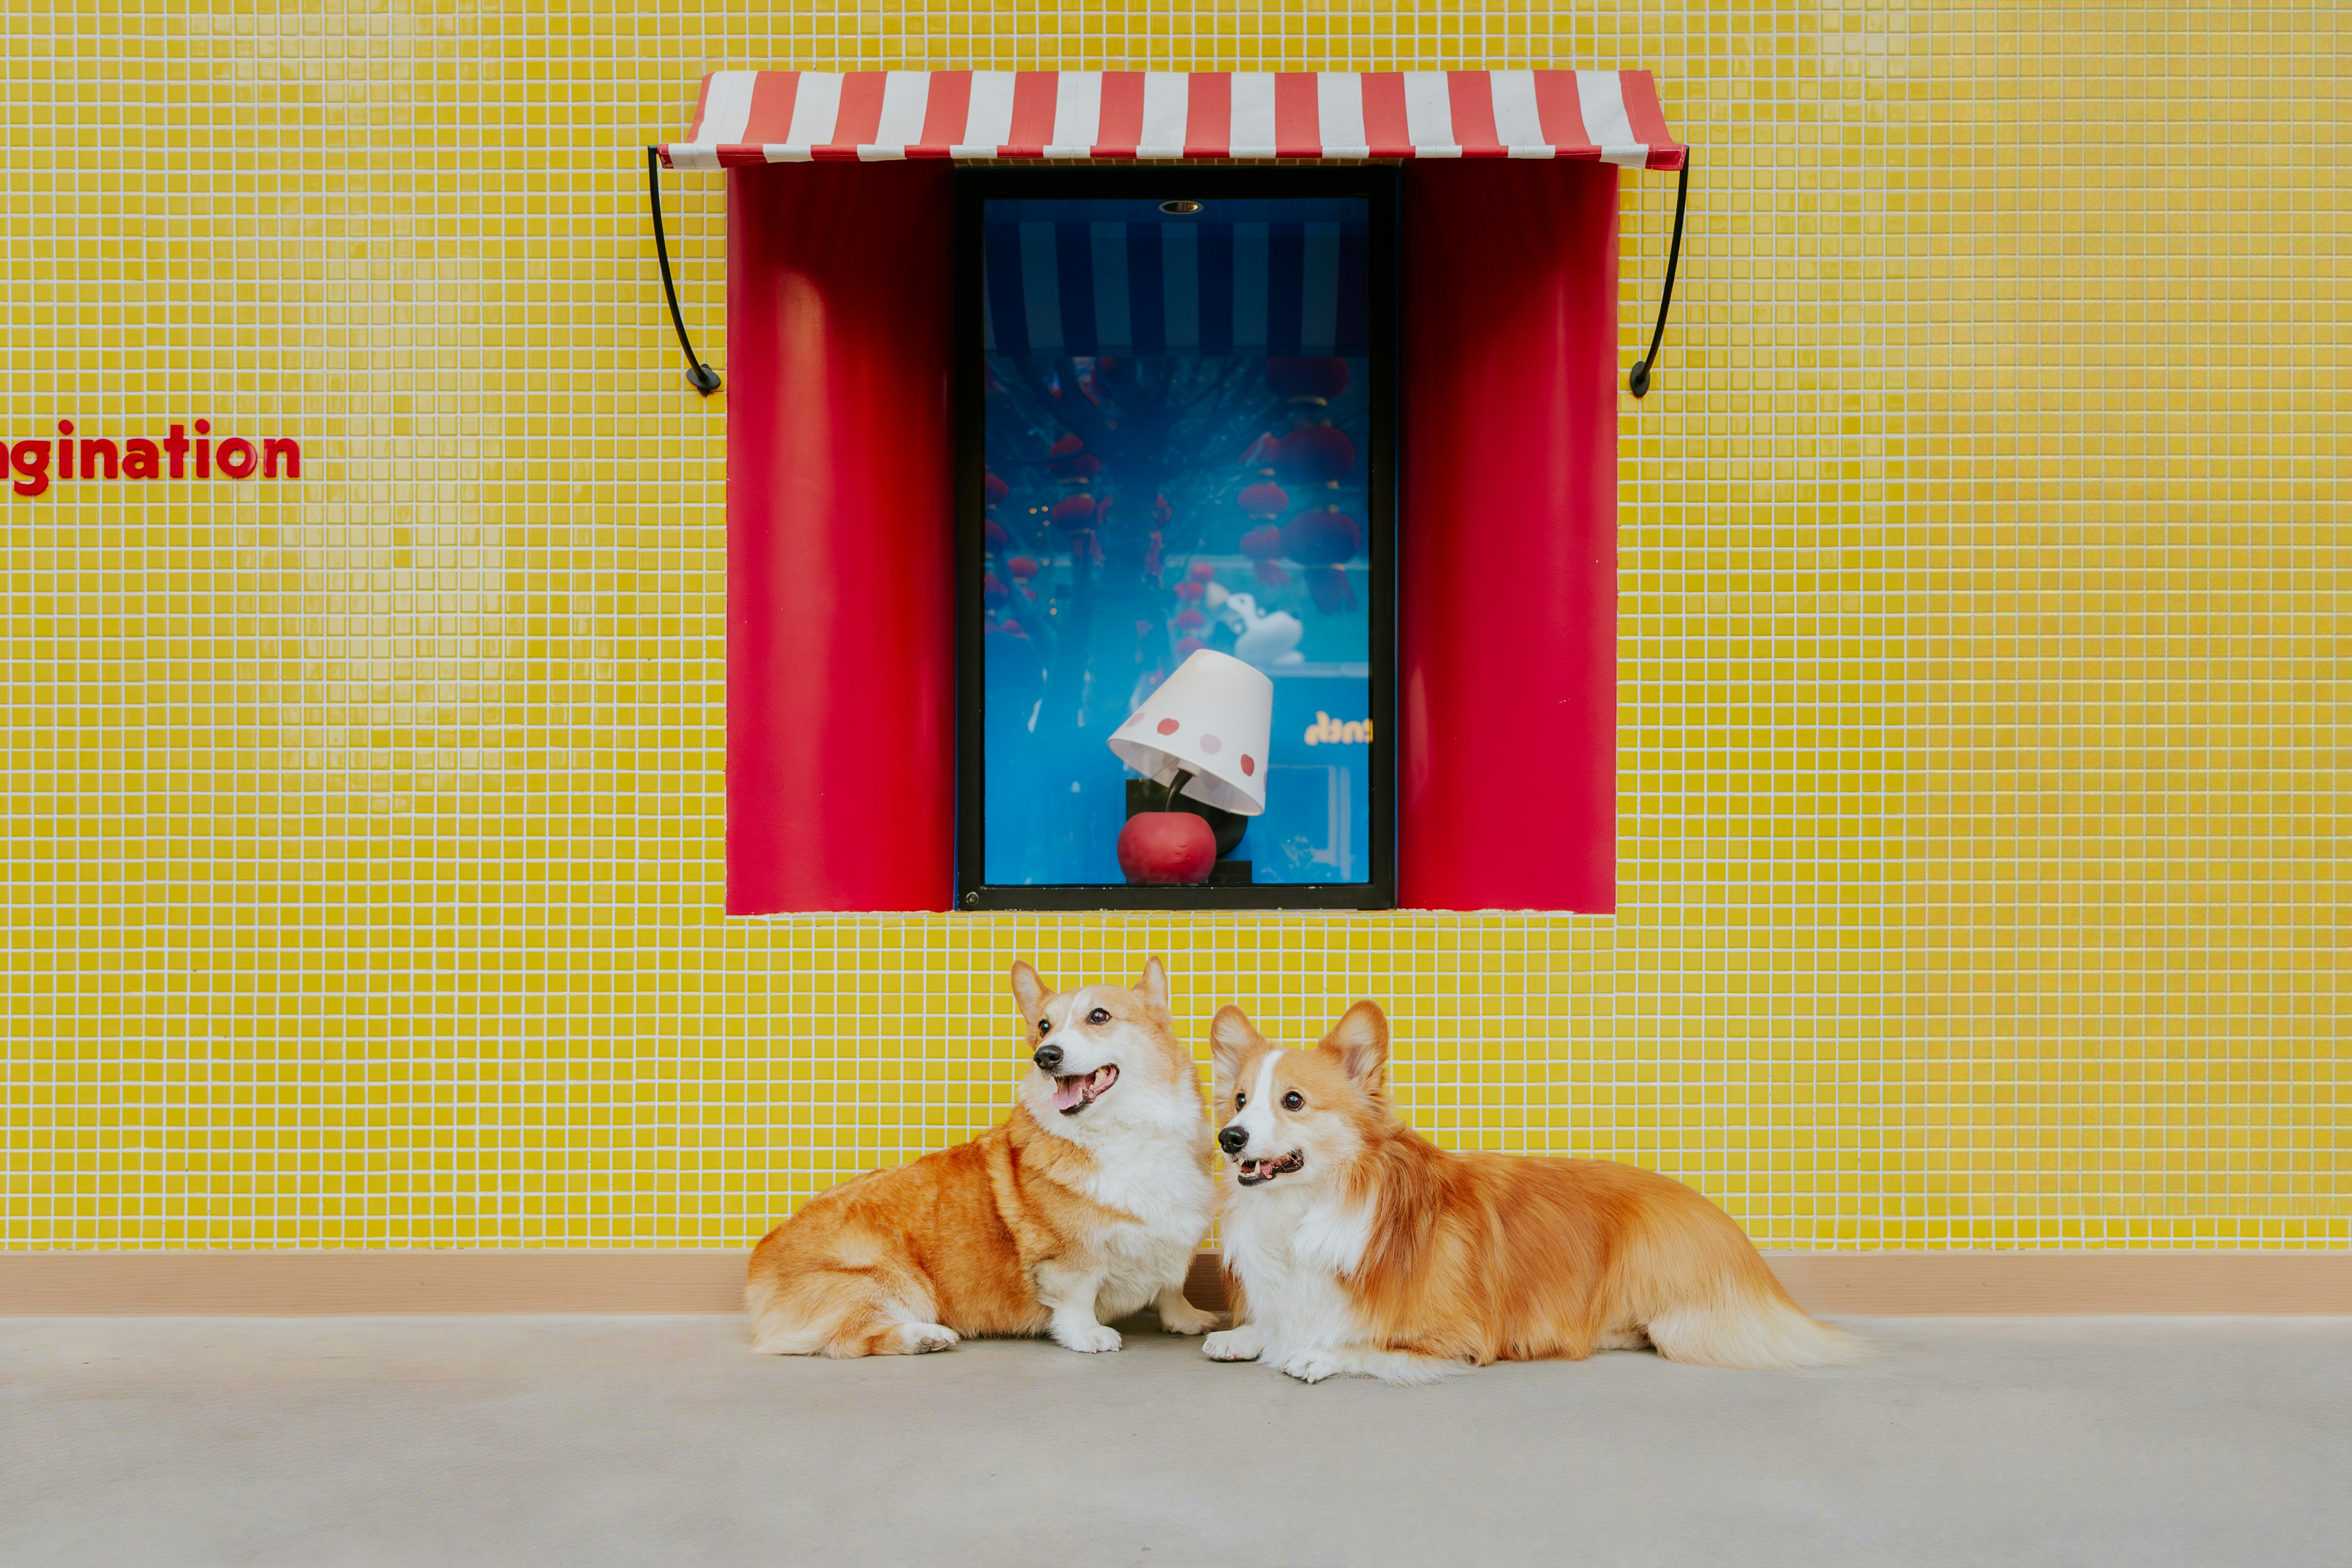

{
  "main_subject": "Two Corgi dogs in front of a colorful wall",
  "detailed_description": "Two fluffy Corgi dogs, one with its mouth open, are sitting side-by-side on a light gray ground. They are positioned in front of a vibrant yellow tiled wall featuring a red-framed window topped with a red and white striped awning. Inside the window, a blue background is visible with decorative elements including a white lampshade with red polka dots and red spherical objects.",
  "visual_elements": [
    "Two Corgi dogs",
    "Yellow tiled wall",
    "Red-framed window",
    "Red and white striped awning",
    "Light gray floor",
    "White lampshade with red polka dots",
    "Red spherical decorations",
    "Blue background (inside window)"
  ],
  "text_content": "gination",
  "search_keywords": [
    "Corgi",
    "dogs",
    "pets",
    "yellow wall",
    "tiled wall",
    "red window",
    "awning",
    "striped awning",
    "cute dogs",
    "animal photography",
    "pet portrait",
    "col

In [9]:
from IPython.display import Image as IPyImage, display

valid_extensions = (".jpg", ".jpeg", ".png", ".webp", ".bmp")
image_files = sorted([p for p in IMAGE_DIR.iterdir() if p.suffix.lower() in valid_extensions])

print("Total images found:", len(image_files))
sample_image = image_files[0]
print("Sample image:", sample_image.name)
display(IPyImage(filename=str(sample_image), width=350))

sample_metadata = generate_search_metadata(sample_image, llm, image_description_prompt)
print(sample_metadata)


## Process All Images


In [10]:
import time

print(f"Starting processing for images in: {IMAGE_DIR}\n")

total_files = len(image_files)
processed_count = 0

for image_path in image_files:
    json_path = JSON_DIR / f"{image_path.stem}.json"

    if json_path.exists():
        print(f"[{processed_count + 1}/{total_files}] Skipping: {image_path.name} (JSON already exists)")
        processed_count += 1
        continue

    print(f"[{processed_count + 1}/{total_files}] Generating metadata for: {image_path.name}...")

    try:
        description = generate_search_metadata(image_path, llm, image_description_prompt)
        if isinstance(description, str):
            description = json.loads(description)

        data = {
            "file_name": image_path.name,
            "file_path": str(image_path.resolve()),
            "description": description,
        }

        with open(json_path, "w", encoding="utf-8") as json_file:
            json.dump(data, json_file, indent=2)

        print(f"   -> Saved to {json_path.name}")
    except Exception as e:
        print(f"   -> Error processing {image_path.name}: {e}")

    processed_count += 1
    time.sleep(5)

print("\nProcessing complete.")


Starting processing for images in: /content/sample_data/Images

[1/17] Generating metadata for: alvan-nee-_mX0sSpVbOg-unsplash.jpg...
   -> Saved to alvan-nee-_mX0sSpVbOg-unsplash.json
[2/17] Generating metadata for: clay-banks-bcaFHquzu3M-unsplash.jpg...
   -> Saved to clay-banks-bcaFHquzu3M-unsplash.json
[3/17] Generating metadata for: clay-banks-nl_jlechVJA-unsplash.jpg...
   -> Saved to clay-banks-nl_jlechVJA-unsplash.json
[4/17] Generating metadata for: georgi-kalaydzhiev-WaxPv3S-EXM-unsplash.jpg...
   -> Saved to georgi-kalaydzhiev-WaxPv3S-EXM-unsplash.json
[5/17] Generating metadata for: helena-lopes-qpimACdCb2I-unsplash.jpg...
   -> Saved to helena-lopes-qpimACdCb2I-unsplash.json
[6/17] Generating metadata for: jessica-fadel-BJE7-y9Sg6o-unsplash.jpg...
   -> Saved to jessica-fadel-BJE7-y9Sg6o-unsplash.json
[7/17] Generating metadata for: land-o-lakes-inc-DJHq_RAw5bo-unsplash.jpg...
   -> Saved to land-o-lakes-inc-DJHq_RAw5bo-unsplash.json
[8/17] Generating metadata for: land-o-

## Create Embeddings and Build the Vector Database


In [17]:
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma

embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

json_files = sorted(JSON_DIR.glob("*.json"))
print("JSON files found:", len(json_files))

documents = []
for json_file in json_files:
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    desc = data.get("description", {})
    page_content = f"""
    Subject: {desc.get('main_subject', 'Unknown')}
    Description: {desc.get('detailed_description', '')}
    Visual Elements: {', '.join(desc.get('visual_elements', []))}
    Keywords: {', '.join(desc.get('search_keywords', []))}
    Mood: {desc.get('dominant_mood', '')}
    Setting: {desc.get('likely_setting', '')}
    Text: {desc.get('text_content', '')}
    """.strip()

    documents.append(
        Document(
            page_content=page_content,
            metadata={
                "file_name": data.get("file_name"),
                "file_path": data.get("file_path"),
                "main_subject": desc.get("main_subject", "Unknown"),
            },
        )
    )

vectorstore = Chroma(
    persist_directory=str(CHROMA_DIR),
    embedding_function=embeddings,
)

existing_count = vectorstore._collection.count()
print("Existing document count:", existing_count)

if existing_count == 0 and documents:
    vectorstore.add_documents(documents)
    print("Documents added to ChromaDB.")
else:
    print("Using existing ChromaDB contents.")

JSON files found: 17
Existing document count: 0
Documents added to ChromaDB.


## List Available Models

In [15]:
import google.generativeai as genai

print("Listing all available Generative AI models:")
for m in genai.list_models():
    if "embedContent" in m.supported_generation_methods:
        print(f"  Embedding Model: {m.name}")
    else:
        print(f"  Other Model: {m.name}")


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Listing all available Generative AI models:
  Other Model: models/gemini-2.5-flash
  Other Model: models/gemini-2.5-pro
  Other Model: models/gemini-2.0-flash
  Other Model: models/gemini-2.0-flash-001
  Other Model: models/gemini-2.0-flash-lite-001
  Other Model: models/gemini-2.0-flash-lite
  Other Model: models/gemini-2.5-flash-preview-tts
  Other Model: models/gemini-2.5-pro-preview-tts
  Other Model: models/gemma-3-1b-it
  Other Model: models/gemma-3-4b-it
  Other Model: models/gemma-3-12b-it
  Other Model: models/gemma-3-27b-it
  Other Model: models/gemma-3n-e4b-it
  Other Model: models/gemma-3n-e2b-it
  Other Model: models/gemini-flash-latest
  Other Model: models/gemini-flash-lite-latest
  Other Model: models/gemini-pro-latest
  Other Model: models/gemini-2.5-flash-lite
  Other Model: models/gemini-2.5-flash-image
  Other Model: models/gemini-2.5-flash-lite-preview-09-2025
  Other Model: models/gemini-3-pro-preview
  Other Model: models/gemini-3-flash-preview
  Other Model: mod

In [16]:
## Retrieval: Search Similar Images

## RAG Step: Answer a Query Using Retrieved Image Context

Retrieval gives us the most relevant images. In the RAG step, we feed the retrieved metadata back into Gemini so it can answer in a grounded way.


In [19]:
def answer_with_image_rag(query, top_k=3):
    retrieved_docs = vectorstore.similarity_search(query, k=top_k)

    if not retrieved_docs:
        print("No supporting images found.")
        return None

    context_blocks = []
    for i, doc in enumerate(retrieved_docs, start=1):
        context_blocks.append(
            f"""
            Image {i}
            File: {doc.metadata.get('file_name')}
            Subject: {doc.metadata.get('main_subject')}
            Context: {doc.page_content}
            """.strip()
        )

    retrieved_context = "\n\n".join(context_blocks)
    rag_prompt = f"""
    You are an assistant answering questions about an image collection.

    User query: {query}

    Use only the retrieved image metadata below. If the answer is uncertain, say so clearly.
    Also mention which image files are the best matches.

    Retrieved context:
    {retrieved_context}
    """

    response = llm.invoke(rag_prompt)
    print(response.content)
    print("\nBest matching files:")
    for doc in retrieved_docs:
        print("-", doc.metadata.get("file_name"))

    return retrieved_docs

In [20]:
answer_with_image_rag("Find images that look like casual social interaction or friends spending time together", top_k=4)


Based on the retrieved image metadata, the following images look like casual social interaction or friends spending time together:

*   **Image 1 (land-o-lakes-inc-DJHq_RAw5bo-unsplash.jpg)**: This image is an excellent match. The description explicitly states "Five women are gathered outdoors, standing and interacting... enjoying a casual conversation." Keywords include "Friends," "Group," "Friendship," and "Conversation." The mood is "Joyful, friendly, relaxed."
*   **Image 3 (land-o-lakes-inc-MdcJY5doCTo-unsplash.jpg)**: This image is an excellent match. The description mentions "smiling and gesturing towards two younger women entering... suggesting a friendly arrival or visit." Keywords include "Friends," "Welcome home," "Smiling women," "Happy moment," and "Home visit." The mood is "Joyful, welcoming, friendly."
*   **Image 4 (microsoft-copilot-3c_k7h8YgHw-unsplash.jpg)**: This image is an excellent match. It shows "Two women in a brightly lit kitchen, one with her back to the vie

[Document(id='1d7f82aa-5026-4268-9d74-9df849f33d21', metadata={'file_name': 'land-o-lakes-inc-DJHq_RAw5bo-unsplash.jpg', 'main_subject': 'A group of five women in a natural, mountainous landscape', 'file_path': '/content/sample_data/Images/land-o-lakes-inc-DJHq_RAw5bo-unsplash.jpg'}, page_content='Subject: A group of five women in a natural, mountainous landscape\n    Description: Five women are gathered outdoors, standing and interacting near a rustic split-rail wooden fence and a wooden plank walkway. They are positioned in a lush green landscape with rolling hills and distant mountains under a partly cloudy sky, framed by dark pine branches in the foreground. The women appear to be enjoying a casual conversation in a serene natural environment.\n    Visual Elements: Five women, Wooden fence, Wooden walkway/board, Green grass, Wildflowers, Pine trees/branches, Mountains, Valley, Cloudy sky, Wire fence\n    Keywords: Women, Friends, Group, Outdoors, Mountain landscape, Rural setting, 